## Model inferencing with pretrained faster rcnn with pytorch

### Imports

In [17]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2 , FasterRCNN_ResNet50_FPN_V2_Weights
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import functional as F

## Download Pretraind Model and Loading

In [18]:
def load_model():
  """
  Load a Pretrained Faster R-Cnn model from torchvision
  """
  weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
  model=fasterrcnn_resnet50_fpn_v2(weights=weights,box_score_thresh=0.7)
  model.eval()
  return model,weights.meta["categories"]


## Image Processing

In [19]:
def preprocess_image(image_path):
  """
  Load And Preprocess an image for the model
  """
  image=Image.open(image_path)
  image_tensor=F.to_tensor(image)
  return image,image_tensor



## Model Prediction

In [20]:
def perform_prediction(model,image_tensor):
  """
  Run inference with the model on the input image
  """
  with torch.no_grad():
    prediction=model([image_tensor])
  print("Model Output")
  print(prediction)
  return prediction[0]


## Class Labels ,confidance Score , Boundin Box Coordinates

### Adding Bounding Box to our results for visualization

In [21]:
def visualize_detections(image,prediction,category_names):
  """
  Visualize the detected objects on the image with bounding box
  """
  image_np=np.array(image)
  image_np=cv2.cvtColor(image_np,cv2.COLOR_RGB2BGR)
  ## Get the predictions
  boxes=prediction["boxes"].cpu().numpy()
  labels=prediction["labels"].cpu().numpy()
  scores=prediction["scores"].cpu().numpy()
  ## Create Copy of the image to draw on
  image_with_boxes=image_np.copy()
  ## Define color map (for Different Class)
  color_map={}

  ## Draw each bounding box
  for box,score,label in zip(boxes,scores,labels):
    if label not in color_map:
      color_map[label]=(
          np.random.randint(0,255),
          np.random.randint(0,255),
          np.random.randint(0,255)
      )
    color=color_map[label]

    ## Draw bounding box
    cv2.rectangle(
    image_with_boxes,
    (int(box[0]), int(box[1])),  # top-left
    (int(box[2]), int(box[3])),  # bottom-right
    color,
    2
    )
    ## Create Label text
    label_text=f"{category_names[label]}:{score:.2f}"
    ## Get text size and baseline
    text_size,baseline=cv2.getTextSize(label_text,cv2.FONT_HERSHEY_SIMPLEX,0.5,1)
    ## Draw label background
    cv2.rectangle(
    image_with_boxes,
    (int(box[0]), int(box[1]) - text_size[1] - 5),
    (int(box[0]) + text_size[0], int(box[1])),
    color,
    -1
    )

    ## Draw label text
    cv2.putText(
    image_with_boxes,
    label_text,
    (int(box[0]), int(box[1]) - 5),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.5,
    (255, 255, 255),
    1,
    cv2.LINE_AA
    )
  ##CONVERT back to rgb for matplotlib
  image_with_boxes=cv2.cvtColor(image_with_boxes,cv2.COLOR_BGR2RGB)

  return image_with_boxes






## Adding all Componants Together for inferencing with main function

In [22]:
def main(image_path):
  """
  Main function to  run object detection and visualization
  """
  model,categories=load_model()
  print(f"Model Loaded with {len(categories)} categories")

  ## Load and preprocessing image
  image,image_tensor=preprocess_image(image_path)
  # Run Detection
  prediction=perform_prediction(model,image_tensor)
  # Get Detection Count
  num_detections=len(prediction["boxes"])
  print(f"Detected {num_detections} objects")
  # Visualize Detection
  result_image=visualize_detections(image,prediction,categories)
  # Display Result
  plt.figure(figsize=(12,8))
  plt.imshow(result_image)
  plt.axis("off")
  plt.tight_layout()
  plt.show()

  ## Print detection details
  print("\ndetection details")
  for i in range(num_detections):
    box=prediction["boxes"][i].cpu().numpy()
    label=prediction["labels"][i].item()
    score=prediction["scores"][i].item()
    print(f"object{i+1}:{categories[label]} ,score:{score:0.2f},Box:{box}")
  return result_image


## Pass the image for inferencing

Model Loaded with 91 categories
Model Output
[{'boxes': tensor([[1.8136e-01, 6.2727e+01, 4.0575e+02, 4.3200e+02],
        [3.0961e+02, 5.3199e+01, 7.0040e+02, 4.0817e+02],
        [1.3936e+02, 1.8780e+00, 2.7086e+02, 3.0125e+02],
        [4.1084e+02, 2.0002e+01, 5.5340e+02, 3.1993e+02]]), 'labels': tensor([19, 19,  1,  1]), 'scores': tensor([0.9997, 0.9994, 0.9989, 0.9979])}]
Detected 4 objects


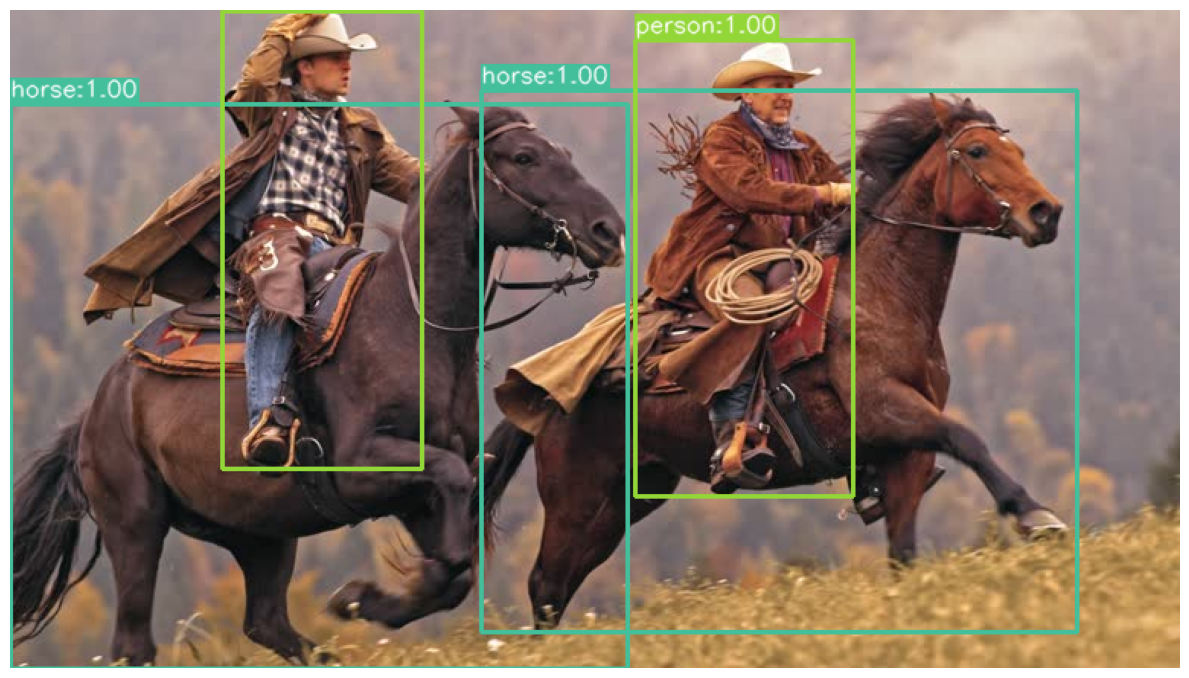


detection details
object1:horse ,score:1.00,Box:[1.8136370e-01 6.2726555e+01 4.0574915e+02 4.3200003e+02]
object2:horse ,score:1.00,Box:[309.60638   53.199097 700.40076  408.1653  ]
object3:person ,score:1.00,Box:[139.35564     1.8780197 270.8602    301.24875  ]
object4:person ,score:1.00,Box:[410.83694   20.002012 553.3957   319.9287  ]


In [23]:
image_path="/content/istockphoto-595723262-640x640.jpg"
result=main(image_path)